# Notebook 09 — Walk-Forward Out-of-Sample Validation

**Adaptive Pair Trading | Ayush Arora (MQMS2404)**

---

## Why Walk-Forward Validation?

A single train/test split is a weak test. Any backtest result could be specific
to the exact split point chosen. Walk-forward validation solves this by:

1. Dividing the 10-year history into **rolling 2-year training + 6-month test windows**
2. Re-estimating the hedge ratio and spread on each training window
3. Measuring performance **only on the held-out test period** for each window
4. Aggregating the out-of-sample test periods into a **distribution of OOS Sharpe ratios**

A strategy is credible only if its OOS Sharpe distribution is:
- Centred above zero (genuine edge, not overfitting)
- Consistent across time periods (not a one-decade fluke)
- Statistically significant (t-test on OOS Sharpe > 0)

This notebook validates **every pair in `data/top_pairs.csv`** (the ranked output
of NB08) — not one hardcoded pair — and reports **per-pair** and **pooled**
out-of-sample results. If `top_pairs.csv` is missing, run NB08 first.

The Z-score is `config.rolling_zscore` throughout — the same 252/60 rolling
definition as NB03 and NB10. The out-of-sample path warm-starts that rolling
window with the tail of the training spread; it does **not** switch to a static
train-mean/std Z-score, so the in-sample vs out-of-sample comparison measures
overfitting rather than a change of strategy.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from dateutil.relativedelta import relativedelta
from scipy import stats
import warnings
from config import (
    PRICES_FILE, TOP_PAIRS_FILE,
    ROLL_WINDOW, ROLL_MIN_PERIODS, rolling_zscore,
    ENTRY_Z, EXIT_Z, TC,
    WF_TRAIN_MONTHS, WF_TEST_MONTHS,
    KF_DELTA, KF_INIT_P
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)

# ── Pairs to validate: whatever NB08 ranked, no hardcoding ────────────────
if not os.path.exists(TOP_PAIRS_FILE):
    raise FileNotFoundError(
        f'{TOP_PAIRS_FILE} not found. Run _08_Universe_Pair_Scan.ipynb first — '
        'it writes the ranked pair list that this notebook validates out-of-sample.'
    )

top_pairs_df = pd.read_csv(TOP_PAIRS_FILE, index_col=0)
PAIRS = [
    (a, b) for a, b in zip(top_pairs_df['Stock A'], top_pairs_df['Stock B'])
    if a in prices.columns and b in prices.columns
]
if not PAIRS:
    raise ValueError(f'No usable pairs in {TOP_PAIRS_FILE}.')

print(f'Price data: {prices.shape}')
print(f'Walk-forward params: {WF_TRAIN_MONTHS}m train / {WF_TEST_MONTHS}m test')
print(f'Strategy: entry ±{ENTRY_Z}σ, exit ±{EXIT_Z}σ, TC {TC*10000:.0f}bps')
print(f'Z-score: config.rolling_zscore (window={ROLL_WINDOW}, min_periods={ROLL_MIN_PERIODS})')
print(f'\nValidating {len(PAIRS)} pair(s) from {TOP_PAIRS_FILE}:')
for i, (a, b) in enumerate(PAIRS, 1):
    print(f'  {i}. {a} / {b}')

Price data: (2467, 79)
Walk-forward params: 24m train / 6m test
Strategy: entry ±2.0σ, exit ±0.5σ, TC 10bps
Z-score: config.rolling_zscore (window=252, min_periods=60)

Validating 3 pair(s) from data/top_pairs.csv:
  1. DABUR.NS / HINDUNILVR.NS
  2. GRASIM.NS / HINDALCO.NS
  3. HINDALCO.NS / TATASTEEL.NS


## Walk-Forward Engine

The engine runs **every pair from `data/top_pairs.csv`** through the same rolling
windows. For each pair and each window it:

1. **Fits OLS** on the training data → gets β and α
2. **Builds the spread** on the test data using those fitted parameters
3. **Computes the rolling Z-score** with `config.rolling_zscore` — the *same*
   252/60 definition used in NB03 and NB10 — warm-started with the tail of the
   training spread so the first test day already has a full window. There is no
   separate static (fixed train μ/σ) Z-score anywhere in this notebook.
4. **Runs the strategy** on the test period only
5. **Records** Sharpe, max drawdown, trade count, hit rate

All strategy parameters (`ENTRY_Z`, `EXIT_Z`, `TC`) are **fixed constants from
`config.py`** — no optimisation per window. Results are reported **per pair** and
**pooled** across every pair × window.

In [3]:
def ols_spread(a, b):
    model = sm.OLS(a, sm.add_constant(b)).fit()
    beta  = model.params.iloc[1]
    alpha = model.params.iloc[0]
    return a - beta * b - alpha, beta, alpha

def zscore_oos(spread_train, spread_test):
    """Out-of-sample Z-score = the SAME rolling_zscore as everywhere else
    (config / NB03 / NB10), warm-started with the tail of the training spread so
    the first test day already sees a full window. No static train-mean/std
    fallback — that would make the IS/OOS comparison compare two strategies."""
    seed     = spread_train.tail(ROLL_WINDOW)
    combined = pd.concat([seed, spread_test])
    return rolling_zscore(combined).loc[spread_test.index]

def run_strategy(zscore, spread, tc=TC):
    """Baseline Z-score strategy. Returns daily % P&L series."""
    spread_mean_abs = spread.dropna().abs().mean()
    spread_ret_pct  = spread.diff() / (spread_mean_abs + 1e-10)
    pos  = pd.Series(0.0, index=zscore.index)
    curr = 0.0
    for t in zscore.index:
        z = zscore.loc[t]
        if pd.isna(z):
            pos.loc[t] = 0.0
            continue
        if curr == 0:
            if   z >  ENTRY_Z: curr = -1.0
            elif z < -ENTRY_Z: curr =  1.0
        elif curr ==  1 and z > -EXIT_Z: curr = 0.0
        elif curr == -1 and z <  EXIT_Z: curr = 0.0
        pos.loc[t] = curr
    trade = pos.diff().abs().fillna(0)
    pnl   = pos.shift(1) * spread_ret_pct - trade * tc
    return pnl.fillna(0), pos

def sharpe(pnl):
    r = pnl[pnl != 0]
    if len(r) < 20:
        return np.nan
    return r.mean() / r.std() * np.sqrt(252)

def max_dd(pnl):
    cum  = (1 + pnl).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min() * 100

def hit_rate(pnl):
    r = pnl[pnl != 0]
    return (r > 0).mean() * 100 if len(r) > 0 else np.nan

print('Walk-forward engine defined.')

Walk-forward engine defined.


In [4]:
def build_windows(index, train_months, test_months):
    """Generate (train_start, train_end, test_start, test_end) tuples."""
    windows = []
    start   = index[0]
    end     = index[-1]
    while True:
        train_end  = start + relativedelta(months=train_months) - relativedelta(days=1)
        test_start = train_end + relativedelta(days=1)
        test_end   = test_start + relativedelta(months=test_months) - relativedelta(days=1)
        if test_end > end:
            break
        windows.append((start, train_end, test_start, test_end))
        start = start + relativedelta(months=test_months)   # roll by test window
    return windows

windows = build_windows(prices.index, WF_TRAIN_MONTHS, WF_TEST_MONTHS)
print(f'Walk-forward windows: {len(windows)}')
for i, (ts, te, ss, se) in enumerate(windows, 1):
    print(f'  Window {i:2d}: Train {ts.date()} → {te.date()} | Test {ss.date()} → {se.date()}')

Walk-forward windows: 16
  Window  1: Train 2015-01-01 → 2016-12-31 | Test 2017-01-01 → 2017-06-30
  Window  2: Train 2015-07-01 → 2017-06-30 | Test 2017-07-01 → 2017-12-31
  Window  3: Train 2016-01-01 → 2017-12-31 | Test 2018-01-01 → 2018-06-30
  Window  4: Train 2016-07-01 → 2018-06-30 | Test 2018-07-01 → 2018-12-31
  Window  5: Train 2017-01-01 → 2018-12-31 | Test 2019-01-01 → 2019-06-30
  Window  6: Train 2017-07-01 → 2019-06-30 | Test 2019-07-01 → 2019-12-31
  Window  7: Train 2018-01-01 → 2019-12-31 | Test 2020-01-01 → 2020-06-30
  Window  8: Train 2018-07-01 → 2020-06-30 | Test 2020-07-01 → 2020-12-31
  Window  9: Train 2019-01-01 → 2020-12-31 | Test 2021-01-01 → 2021-06-30
  Window 10: Train 2019-07-01 → 2021-06-30 | Test 2021-07-01 → 2021-12-31
  Window 11: Train 2020-01-01 → 2021-12-31 | Test 2022-01-01 → 2022-06-30
  Window 12: Train 2020-07-01 → 2022-06-30 | Test 2022-07-01 → 2022-12-31
  Window 13: Train 2021-01-01 → 2022-12-31 | Test 2023-01-01 → 2023-06-30
  Window 14: 

In [5]:
def walk_forward_pair(a_col, b_col):
    """Run the walk-forward backtest for one pair. Returns (results_df, oos_pnl_list)."""
    A = prices[a_col]
    B = prices[b_col]
    rows, oos_pnl = [], []
    for i, (train_s, train_e, test_s, test_e) in enumerate(windows, 1):
        a_train = A.loc[train_s:train_e].dropna()
        b_train = B.loc[train_s:train_e].dropna()
        if len(a_train) < 60:
            continue
        spread_train, beta, alpha = ols_spread(a_train, b_train)

        a_test = A.loc[test_s:test_e].dropna()
        b_test = B.loc[test_s:test_e].dropna()
        if len(a_test) < 20:
            continue
        spread_test = a_test - beta * b_test - alpha
        zscore_test = zscore_oos(spread_train, spread_test)   # seeded rolling Z

        pnl_test, pos_test = run_strategy(zscore_test, spread_test)
        pnl_test.name = f'{a_col}/{b_col}'
        trades = int((pos_test.diff().abs() > 0).sum() // 2)

        rows.append({
            'Pair':        f'{a_col}/{b_col}',
            'Window':      i,
            'Test Start':  test_s.date(),
            'Test End':    test_e.date(),
            'Beta (OLS)':  round(beta, 4),
            'OOS Sharpe':  round(sharpe(pnl_test), 3),
            'OOS Max DD%': round(max_dd(pnl_test), 2),
            'Hit Rate%':   round(hit_rate(pnl_test), 1),
            'Trades':      trades,
        })
        oos_pnl.append(pnl_test)
    return pd.DataFrame(rows), oos_pnl


print('Running walk-forward backtest over all pairs...\n')
wf_by_pair, oos_pnl_by_pair = {}, {}
for a_col, b_col in PAIRS:
    wdf, opnl = walk_forward_pair(a_col, b_col)
    wf_by_pair[(a_col, b_col)]      = wdf
    oos_pnl_by_pair[(a_col, b_col)] = opnl
    n_valid = int(wdf['OOS Sharpe'].notna().sum()) if len(wdf) else 0
    print(f'  {a_col}/{b_col:<16s}  {len(wdf):2d} windows run, {n_valid:2d} with a valid Sharpe')

wf_df = pd.concat(wf_by_pair.values(), ignore_index=True)
print(f'\nTotal pair-windows: {len(wf_df)}')
wf_df

Running walk-forward backtest over all pairs...



  DABUR.NS/HINDUNILVR.NS     16 windows run, 10 with a valid Sharpe


  GRASIM.NS/HINDALCO.NS       16 windows run, 11 with a valid Sharpe


  HINDALCO.NS/TATASTEEL.NS      16 windows run,  9 with a valid Sharpe

Total pair-windows: 48


,Pair,Window,Test Start,Test End,Beta (OLS),OOS Sharpe,OOS Max DD%,Hit Rate%,Trades
0,DABUR.NS/HINDUNILVR.NS,1,2017-01-01,2017-06-30,0.2246,-2.195,-91.94,47.6,0
1,DABUR.NS/HINDUNILVR.NS,2,2017-07-01,2017-12-31,0.0979,-0.461,-130.78,48.8,0
2,DABUR.NS/HINDUNILVR.NS,3,2018-01-01,2018-06-30,0.1302,4.122,-72.80,57.1,1
3,DABUR.NS/HINDUNILVR.NS,4,2018-07-01,2018-12-31,0.1359,0.267,-91.29,53.3,1
4,DABUR.NS/HINDUNILVR.NS,5,2019-01-01,2019-06-30,0.1882,NaN,0.00,NaN,0
5,DABUR.NS/HINDUNILVR.NS,6,2019-07-01,2019-12-31,0.2008,NaN,0.00,NaN,0
6,DABUR.NS/HINDUNILVR.NS,7,2020-01-01,2020-06-30,0.1808,NaN,-111.79,50.0,1
7,DABUR.NS/HINDUNILVR.NS,8,2020-07-01,2020-12-31,0.1357,1.337,-86.22,58.7,1
8,DABUR.NS/HINDUNILVR.NS,9,2021-01-01,2021-06-30,0.1699,NaN,0.00,NaN,0
9,DABUR.NS/HINDUNILVR.NS,10,2021-07-01,2021-12-31,0.1905,2.140,-68.80,56.8,2


## OOS Performance Analysis

In [6]:
# ── Per-pair OOS summary ─────────────────────────────────────────────────
per_pair_rows = []
for (a_col, b_col), wdf in wf_by_pair.items():
    s = wdf['OOS Sharpe'].dropna()
    t_stat, p_val = stats.ttest_1samp(s, 0) if len(s) >= 2 else (np.nan, np.nan)
    per_pair_rows.append({
        'Pair':            f'{a_col}/{b_col}',
        'Windows':         len(s),
        'Mean OOS Sharpe': round(s.mean(), 3) if len(s) else np.nan,
        'Median':          round(s.median(), 3) if len(s) else np.nan,
        'Std':             round(s.std(), 3) if len(s) else np.nan,
        'Pos':             f'{int((s > 0).sum())}/{len(s)}',
        't-stat':          round(t_stat, 3),
        'p-value':         round(p_val, 4),
    })
per_pair = pd.DataFrame(per_pair_rows)
print('=== PER-PAIR OUT-OF-SAMPLE SUMMARY ===')
print(per_pair.to_string(index=False))

# ── Pooled across every pair x window ────────────────────────────────────
pooled = wf_df['OOS Sharpe'].dropna()
t_stat, p_val = stats.ttest_1samp(pooled, 0)
print('\n=== POOLED OOS PERFORMANCE (all pairs x windows) ===')
print(f'Observations (pair-windows) : {len(pooled)}')
print(f'Mean OOS Sharpe             : {pooled.mean():+.3f}')
print(f'Median OOS Sharpe           : {pooled.median():+.3f}')
print(f'Std OOS Sharpe              : {pooled.std():.3f}')
print(f'Positive                    : {(pooled > 0).sum()} / {len(pooled)} ({(pooled > 0).mean()*100:.0f}%)')
print(f'Sharpe > 0.5                : {(pooled > 0.5).sum()} / {len(pooled)}')
print(f't-statistic (H0: mean = 0)  : {t_stat:.3f}')
print(f'p-value                     : {p_val:.4f}  ->  {"Significant" if p_val < 0.05 else "Not significant"} at 5%')

# Mean OOS Sharpe across pairs, each pair weighted equally
pair_means = per_pair.set_index('Pair')['Mean OOS Sharpe'].dropna()
if len(pair_means) >= 2:
    t2, p2 = stats.ttest_1samp(pair_means, 0)
    print(f'\nEqual-weight across pairs   : mean {pair_means.mean():+.3f}  '
          f't={t2:.3f}  p={p2:.4f}')

# ── Equal-weight pooled OOS equity curve ─────────────────────────────────
pair_curves = {
    f'{a}/{b}': pd.concat(opnl).sort_index()
    for (a, b), opnl in oos_pnl_by_pair.items() if opnl
}
oos_panel    = pd.DataFrame(pair_curves)
oos_combined = oos_panel.mean(axis=1)                       # equal weight, active pairs
oos_cum      = (1 + oos_combined.fillna(0)).cumprod() - 1
print(f'\nPooled OOS equity curve: {oos_panel.shape[1]} pair(s), '
      f'{oos_panel.index.min().date()} -> {oos_panel.index.max().date()}, '
      f'final cumulative return {oos_cum.iloc[-1]*100:+.1f}%')

=== PER-PAIR OUT-OF-SAMPLE SUMMARY ===
                    Pair  Windows  Mean OOS Sharpe  Median   Std  Pos  t-stat  p-value
  DABUR.NS/HINDUNILVR.NS       10            0.592   0.760 1.866 7/10   1.003   0.3419
   GRASIM.NS/HINDALCO.NS       11            1.013   0.389 2.156 7/11   1.559   0.1501
HINDALCO.NS/TATASTEEL.NS        9            0.573   0.471 0.887  7/9   1.939   0.0885

=== POOLED OOS PERFORMANCE (all pairs x windows) ===
Observations (pair-windows) : 30
Mean OOS Sharpe             : +0.741
Median OOS Sharpe           : +0.521
Std OOS Sharpe              : 1.716
Positive                    : 21 / 30 (70%)
Sharpe > 0.5                : 15 / 30
t-statistic (H0: mean = 0)  : 2.365
p-value                     : 0.0250  ->  Significant at 5%

Equal-weight across pairs   : mean +0.726  t=5.056  p=0.0370

Pooled OOS equity curve: 3 pair(s), 2017-01-02 -> 2024-12-31, final cumulative return +1058.2%


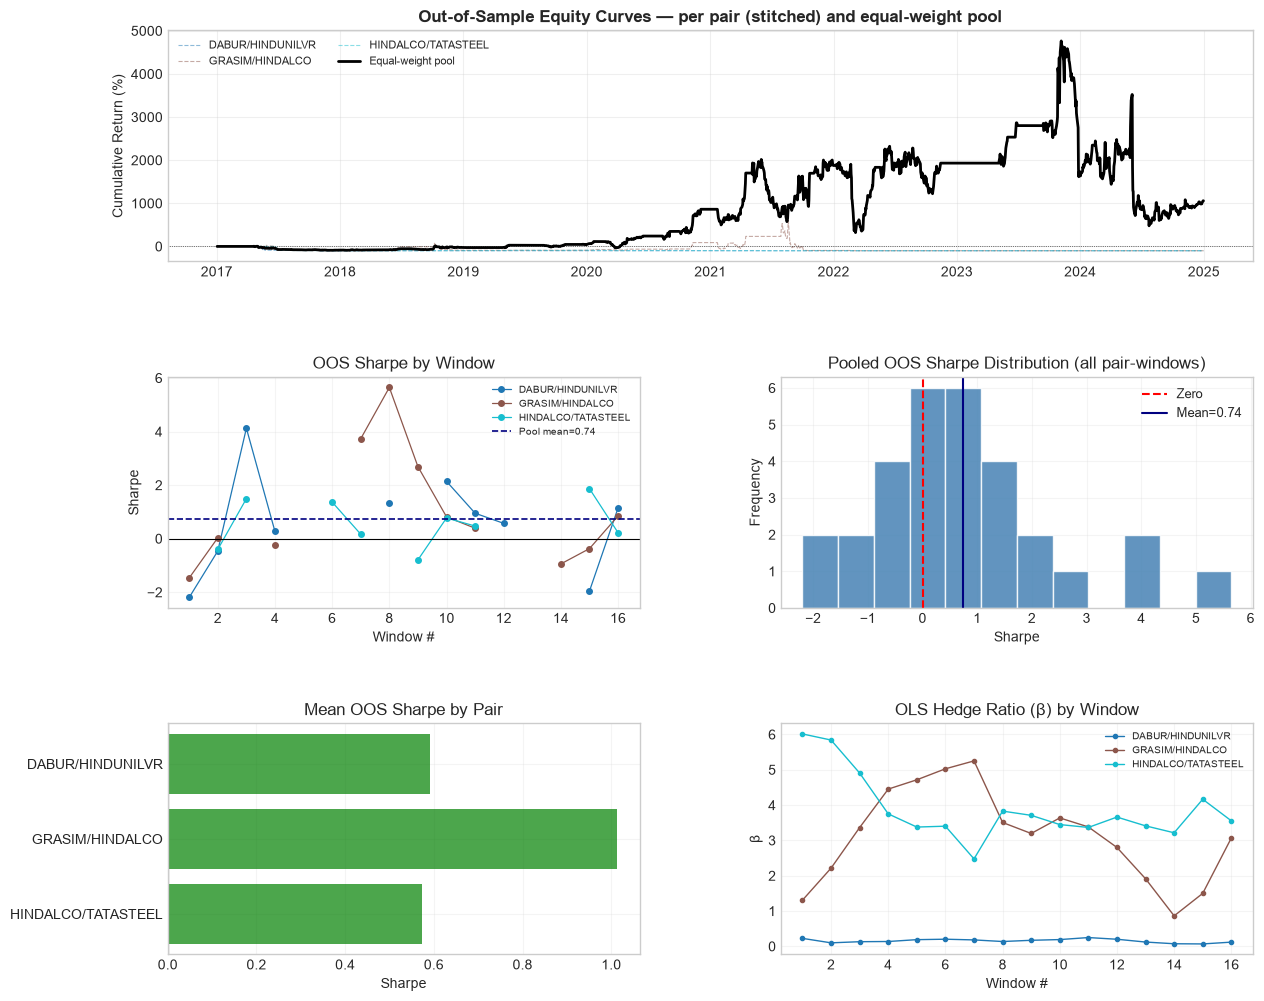

In [7]:
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.5, wspace=0.3)
pair_labels = [f'{a}/{b}'.replace('.NS', '') for a, b in PAIRS]
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(PAIRS), 1)))

# ── 1. Pooled + per-pair OOS equity curves ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for k, col in enumerate(oos_panel.columns):
    ci = (1 + oos_panel[col].fillna(0)).cumprod() - 1
    ax1.plot(ci * 100, linewidth=0.8, alpha=0.5, linestyle='--',
             color=cmap[k], label=f'{col}'.replace('.NS', ''))
ax1.plot(oos_cum * 100, color='black', linewidth=2.0, label='Equal-weight pool')
ax1.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax1.set_title('Out-of-Sample Equity Curves — per pair (stitched) and equal-weight pool',
              fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

# ── 2. OOS Sharpe by window, coloured by pair ───────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
for k, ((a, b), wdf) in enumerate(wf_by_pair.items()):
    ax2.plot(wdf['Window'], wdf['OOS Sharpe'], marker='o', markersize=4,
             linewidth=0.9, color=cmap[k], label=f'{a}/{b}'.replace('.NS', ''))
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(pooled.mean(), color='navy', linestyle='--', linewidth=1.2,
            label=f'Pool mean={pooled.mean():.2f}')
ax2.set_title('OOS Sharpe by Window')
ax2.set_xlabel('Window #'); ax2.set_ylabel('Sharpe')
ax2.legend(fontsize=7); ax2.grid(alpha=0.2)

# ── 3. Pooled OOS Sharpe distribution ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(pooled, bins=min(12, max(len(pooled), 3)),
         color='steelblue', edgecolor='white', alpha=0.85)
ax3.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero')
ax3.axvline(pooled.mean(), color='navy', linewidth=1.5,
            label=f'Mean={pooled.mean():.2f}')
ax3.set_title('Pooled OOS Sharpe Distribution (all pair-windows)')
ax3.set_xlabel('Sharpe'); ax3.set_ylabel('Frequency')
ax3.legend(fontsize=9); ax3.grid(alpha=0.2)

# ── 4. Per-pair mean OOS Sharpe ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
means = per_pair['Mean OOS Sharpe'].values
ax4.barh(pair_labels[::-1], means[::-1],
         color=['green' if m > 0 else 'red' for m in means[::-1]], alpha=0.7)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('Mean OOS Sharpe by Pair')
ax4.set_xlabel('Sharpe'); ax4.grid(alpha=0.2)

# ── 5. OLS beta stability per pair ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
for k, ((a, b), wdf) in enumerate(wf_by_pair.items()):
    if len(wdf):
        ax5.plot(wdf['Window'], wdf['Beta (OLS)'], marker='o', markersize=3,
                 linewidth=1.0, color=cmap[k], label=f'{a}/{b}'.replace('.NS', ''))
ax5.set_title('OLS Hedge Ratio (β) by Window')
ax5.set_xlabel('Window #'); ax5.set_ylabel('β')
ax5.legend(fontsize=7); ax5.grid(alpha=0.2)

plt.savefig('walk_forward_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── In-sample vs out-of-sample Sharpe — SAME strategy, different period ───
# IS and OOS both use config.rolling_zscore (252/60). The only difference is
# the period: IS = training window, OOS = held-out test window. So the gap
# measures overfitting, not a change of strategy.
def insample_sharpes(a_col, b_col):
    A, B = prices[a_col], prices[b_col]
    out = []
    for train_s, train_e, test_s, test_e in windows:
        a_tr = A.loc[train_s:train_e].dropna()
        b_tr = B.loc[train_s:train_e].dropna()
        if len(a_tr) < 60:
            continue
        spread_tr, beta, alpha = ols_spread(a_tr, b_tr)
        zscore_tr = rolling_zscore(spread_tr)          # identical definition to OOS
        pnl_tr, _ = run_strategy(zscore_tr, spread_tr)
        out.append(sharpe(pnl_tr))
    return pd.Series(out, dtype=float)

rows, is_all, oos_all = [], [], []
for (a_col, b_col), wdf in wf_by_pair.items():
    is_s  = insample_sharpes(a_col, b_col).dropna()
    oos_s = wdf['OOS Sharpe'].dropna()
    is_all.extend(is_s.tolist())
    oos_all.extend(oos_s.tolist())
    rows.append({
        'Pair':            f'{a_col}/{b_col}',
        'IS mean Sharpe':  round(is_s.mean(), 3),
        'OOS mean Sharpe': round(oos_s.mean(), 3),
        'Gap (IS - OOS)':  round(is_s.mean() - oos_s.mean(), 3),
    })
gap_df = pd.DataFrame(rows)

print('=== IN-SAMPLE vs OUT-OF-SAMPLE SHARPE (same rolling Z-score) ===')
print(gap_df.to_string(index=False))

is_all, oos_all = np.array(is_all), np.array(oos_all)
print(f'\nPooled IS  mean Sharpe : {np.nanmean(is_all):+.3f}  (n={np.isfinite(is_all).sum()})')
print(f'Pooled OOS mean Sharpe : {np.nanmean(oos_all):+.3f}  (n={np.isfinite(oos_all).sum()})')
print(f'Overfitting gap (IS - OOS): {np.nanmean(is_all) - np.nanmean(oos_all):+.3f}')
print(f'IS > OOS (overfitting signal): {np.nanmean(is_all) > np.nanmean(oos_all)}')

=== IN-SAMPLE vs OUT-OF-SAMPLE SHARPE (same rolling Z-score) ===
                    Pair  IS mean Sharpe  OOS mean Sharpe  Gap (IS - OOS)
  DABUR.NS/HINDUNILVR.NS           1.668            0.592           1.077
   GRASIM.NS/HINDALCO.NS           2.019            1.013           1.006
HINDALCO.NS/TATASTEEL.NS           2.005            0.573           1.432

Pooled IS  mean Sharpe : +1.898  (n=48)
Pooled OOS mean Sharpe : +0.741  (n=30)
Overfitting gap (IS - OOS): +1.157
IS > OOS (overfitting signal): True


## Conclusion

### Interpretation guide

| Result | Interpretation |
|--------|---------------|
| Mean OOS Sharpe > 0 & p < 0.05 | Statistically significant edge — strategy has genuine predictive power |
| Mean OOS Sharpe > 0 & p > 0.05 | Positive but not yet significant — more data or pairs needed |
| Mean OOS Sharpe < 0 | No edge — strategy needs redesign |
| IS Sharpe ≈ OOS Sharpe | Low overfitting — fixed parameters generalise well |
| IS Sharpe >> OOS Sharpe | Overfitting — parameters optimised in-sample, fail OOS |

### Key design safeguards
- **Pairs come from NB08** — `data/top_pairs.csv` is read directly; no pair is hardcoded, and a missing file raises rather than silently substituting a default.
- **One Z-score everywhere** — `config.rolling_zscore` (252/60) is used for both the in-sample and out-of-sample paths. The OOS path only warm-starts the rolling window with the training-spread tail; it never falls back to a static train μ/σ Z-score.
- **No parameter optimisation per window** — `ENTRY_Z`, `EXIT_Z`, `TC` are fixed constants from `config.py`.
- **Rolling windows prevent look-ahead** — the hedge ratio β for each window is estimated on that window's training data only.
- **Per-pair and pooled reporting** — each pair gets its own OOS Sharpe distribution and t-test; the pooled view aggregates every pair × window.

This notebook provides the academic rigour to defend the strategy's validity against
the standard critique: *"any backtest can be made to look good in-sample."*